In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import os
import glob
import random

In [2]:
# def build_organic_cluster_layout(graph, tf_list, gene_list):
#     import random
#     random.seed(42)
#     np.random.seed(42)
    
#     pos = {}
    
#     # 步骤 1：宏观布局 - 将核心 TF 彻底推开（增大半径）
#     if len(tf_list) == 1:
#         pos[tf_list[0]] = np.array([0.0, 0.0])
#     else:
#         # 【修改点 1】增大TF之间的距离，从 len(tf_list) * 20 增加到 len(tf_list) * 40
#         tf_radius = max(120, len(tf_list) * 80)  
#         angles = np.linspace(0, 2 * np.pi, len(tf_list), endpoint=False)
#         for i, tf in enumerate(tf_list):
#             pos[tf] = np.array([tf_radius * np.cos(angles[i]), tf_radius * np.sin(angles[i])])

#     # 步骤 2：微观布局 - 手动制造紧凑但略微拉开的"星爆"簇
#     for gene in gene_list:
#         parents = list(graph.predecessors(gene))
#         if len(parents) == 1:
#             # 独有靶基因：紧紧围绕唯一的 TF
#             center = pos[parents[0]]
#             angle = np.random.uniform(0.5, 2 * np.pi)
            
#             # 【修改点 2】调大半径范围（从 0.6~0.7 放大到 0.8~1.2），让TF到Gene的连线更长
#             r = np.random.uniform(0.1, 0.2)
#             # 高亮基因半径平均 1.5 倍
#             if gene in highlight_genes:
#                 r = r * 1.5
#             pos[gene] = center + np.array([r * np.cos(angle), r * np.sin(angle)])
#         elif len(parents) > 1:
#             # 共享靶基因：拉到多个 TF 的几何中心
#             center = np.mean([pos[p] for p in parents if p in pos], axis=0)
#             noise = np.random.uniform(-0.05, 0.05, 2)  # 增加一些随机性
#             if gene in highlight_genes:
#                 noise = noise * 1.5
#             pos[gene] = center + noise
#         else:
#             pos[gene] = np.array([0, 0])

#     # 步骤 3：物理微调 (只允许基因动，TF不动)
#     pos = nx.spring_layout(
#         graph, 
#         pos=pos,          
#         fixed=tf_list,    # 锁定 TF 节点坐标
#         k=0.06,           # 【修改点 3】减小k值，让节点之间更分散
#         iterations=30,    # 增加迭代次数
#         seed=42
#     )
#     return pos

# def visualize_regulatory_network(metadata_df, importance_col='importance', weight_col='importance_TF2G', figure_size=(15, 9),
#                                top_n=100, output_html='figures/network.html', title='SCENIC+ Regulatory Network', df_deg=None,
#                                highlight_genes=None):
#     from pyvis.network import Network

#     if metadata_df.empty:
#         raise ValueError('metadata_df is empty after filtering.')

#     if importance_col not in metadata_df.columns:
#         raise KeyError(f'{importance_col} not found in metadata_df')

#     if weight_col not in metadata_df.columns:
#         metadata_df = metadata_df.copy()
#         metadata_df[weight_col] = metadata_df[importance_col]

#     df = metadata_df.sort_values(importance_col, ascending=False).head(top_n).copy()

#     if df_deg is None:
#         df_deg_plot = pd.DataFrame(columns=['gene', 'condition', 'de_coef'])
#     else:
#         df_deg_plot = df_deg.copy()
#         if 'gene' not in df_deg_plot.columns:
#             gene_col = next((col for col in ['Gene', 'targetgene', 'TF'] if col in df_deg_plot.columns), None)
#             if gene_col is None:
#                 raise KeyError('df_deg must contain a gene-like column.')
#             df_deg_plot = df_deg_plot.rename(columns={gene_col: 'gene'})
#         if 'de_coef' not in df_deg_plot.columns:
#             coef_col = next((col for col in ['de_coef', 'log2FC'] if col in df_deg_plot.columns), None)
#             if coef_col is None:
#                 raise KeyError('df_deg must contain de_coef or log2FC.')
#             df_deg_plot = df_deg_plot.rename(columns={coef_col: 'de_coef'})
#         if 'condition' not in df_deg_plot.columns:
#             df_deg_plot['condition'] = np.where(df_deg_plot['de_coef'] > 0, 'UP', 'DOWN')
#         df_deg_plot['gene'] = df_deg_plot['gene'].astype(str).str.upper()
#         df_deg_plot = df_deg_plot.sort_values('de_coef', key=lambda s: s.abs(), ascending=False).drop_duplicates('gene')

#     df['TF'] = df['TF'].astype(str).str.upper()
#     df['Gene'] = df['Gene'].astype(str).str.upper()

#     G = nx.DiGraph()
#     for _, row in df.iterrows():
#         G.add_edge(
#             row['TF'],
#             row['Gene'],
#             weight=row[weight_col],
#             title=f"Weight: {row[weight_col]:.2f}"
#         )

#     def format_label(name):
#         name = str(name).strip()
#         return name[:1].upper() + name[1:].lower() if name else name

#     degrees = dict(G.degree())
#     max_degree = max(degrees.values()) if degrees else 1
#     tf_nodes = sorted(df['TF'].unique())
#     tf_node_set = set(tf_nodes)
#     gene_nodes = sorted([node for node in G.nodes() if node not in tf_node_set])
#     deg_lookup = df_deg_plot.set_index('gene')[['condition', 'de_coef']].to_dict('index') if not df_deg_plot.empty else {}

#     node_colors = {}
#     node_edge_colors = {}
#     node_edge_widths = {}

#     for node in G.nodes():
#         is_tf = node in tf_node_set
#         deg_info = deg_lookup.get(node)
#         if deg_info is not None and deg_info['condition'] == 'UP':
#             fill_color = '#E86A33' if is_tf else '#F3A26D'
#             edge_color = '#C9511C'
#             edge_width = 3 if is_tf else 0
#         elif deg_info is not None and deg_info['condition'] == 'DOWN':
#             fill_color = '#3A86C8' if is_tf else '#8EC0E6'
#             edge_color = '#2C6BA0'
#             edge_width = 3 if is_tf else 0
#         else:
#             if is_tf:
#                 fill_color = '#FFD700'
#                 edge_color = '#DAA520'
#                 edge_width = 1.5
#             else:
#                 fill_color = 'lightgray'
#                 edge_color = 'lightgray'
#                 edge_width = 0

#         node_colors[node] = fill_color
#         node_edge_colors[node] = edge_color
#         node_edge_widths[node] = edge_width

#     plt.figure(figsize=figure_size)
#     pos = build_organic_cluster_layout(G, tf_nodes, gene_nodes, highlight_genes=highlight_genes)    

#     node_sizes = []
#     for node in G.nodes():
#         deg_info = deg_lookup.get(node)
#         base_size = 260 if node in tf_node_set else 120
#         degree_size = degrees[node] * (900 if node in tf_node_set else 380) / max_degree
#         if deg_info is not None:
#             fold_change = abs(deg_info['de_coef']) * (520 if node in tf_node_set else 320)
#         else:
#             fold_change = 0
#         total_size = base_size + degree_size + fold_change
#         # 高亮基因节点 1.5 倍大小
#         if node in highlight_genes:
#             total_size = total_size * 1.5
#         node_sizes.append(total_size)

#     # 只有高亮基因才显示文字标签
#     highlight_genes_set = set(highlight_genes) if highlight_genes else set()
#     tf_labels = {node: format_label(node) for node in tf_nodes if node in pos}
#     gene_labels = {node: format_label(node) for node in gene_nodes if node in pos and node in highlight_genes_set}
#     tf_text_labels = nx.draw_networkx_labels(
#         G, pos, labels=tf_labels, font_size=10, font_family='sans-serif',
#         bbox=dict(facecolor='none', pad=0.1, edgecolor='none')
#     )
#     gene_text_labels = nx.draw_networkx_labels(
#         G, pos, labels=gene_labels, font_size=7, font_family='sans-serif',
#         bbox=dict(facecolor='none', pad=0.05, edgecolor='none')
#     )
#     for _, label in {**tf_text_labels, **gene_text_labels}.items():
#         label.set_path_effects([
#             path_effects.Stroke(linewidth=2, foreground='white'),
#             path_effects.Normal()
#         ])

#     plt.title(title)
#     plt.axis('off')
#     plt.tight_layout()
#     output_dir = os.path.dirname(output_html)
#     if output_dir:
#         os.makedirs(output_dir, exist_ok=True)
#     plt.savefig(output_html + '.png', dpi=300)
#     plt.show()

#     # Pyvis HTML 部分保持原样不变
#     net = Network(height='800px', width='100%', directed=True)
#     net.from_nx(G)
#     for node in net.nodes:
#         node['label'] = format_label(node['id'])
#         if node['id'] in tf_node_set:
#             node['shape'] = 'triangle'
#             node['size'] = 28
#         else:
#             node['size'] = 16
#     net.barnes_hut(gravity=-25000, central_gravity=0.15, spring_length=140, spring_strength=0.02, damping=0.95)
#     net.show_buttons(filter_=['physics'])
#     net.save_graph(output_html)
#     print(f'Interactive visualization saved to {output_html}')


In [ ]:
def build_organic_cluster_layout(graph, tf_list, gene_list, highlight_genes=None):
    import random
    random.seed(42)
    np.random.seed(42)
    
    pos = {}
    
    # 步骤 1：宏观布局 - 将核心 TF 彻底推开（增大半径）
    if len(tf_list) == 1:
        pos[tf_list[0]] = np.array([0.0, 0.0])
    else:
        # 【修改点 1】增大TF之间的距离，从 len(tf_list) * 20 增加到 len(tf_list) * 40
        tf_radius = max(60, len(tf_list) * 20)  
        angles = np.linspace(0, 2 * np.pi, len(tf_list), endpoint=False)
        for i, tf in enumerate(tf_list):
            pos[tf] = np.array([tf_radius * np.cos(angles[i]), tf_radius * np.sin(angles[i])])

    highlight_set = set(highlight_genes) if highlight_genes else set()

    # 步骤 2：微观布局 - 手动制造紧凑但略微拉开的"星爆"簇
    for gene in gene_list:
        parents = list(graph.predecessors(gene))
        if len(parents) == 1:
            # 独有靶基因：紧紧围绕唯一的 TF
            center = pos[parents[0]]
            angle = np.random.uniform(0.5, 2 * np.pi)
            
            # 【修改点 2】调大半径范围（从 0.6~0.7 放大到 0.8~1.2），让TF到Gene的连线更长
            r = np.random.uniform(0.1, 0.2)
            # 高亮基因半径平均 1.5 倍
            if gene in highlight_set:
                r = r * 1.5
            pos[gene] = center + np.array([r * np.cos(angle), r * np.sin(angle)])
        elif len(parents) > 1:
            # 共享靶基因：拉到多个 TF 的几何中心
            center = np.mean([pos[p] for p in parents if p in pos], axis=0)
            noise = np.random.uniform(-0.05, 0.05, 2)  # 增加一些随机性
            if gene in highlight_set:
                noise = noise * 1.5
            pos[gene] = center + noise
        else:
            pos[gene] = np.array([0, 0])

    # 步骤 3：物理微调 (只允许基因动，TF不动)
    pos = nx.spring_layout(
        graph, 
        pos=pos,          
        fixed=tf_list,    # 锁定 TF 节点坐标
        k=0.06,           # 【修改点 3】减小k值，让节点之间更分散
        iterations=30,    # 增加迭代次数
        seed=42
    )
    return pos

def visualize_regulatory_network(metadata_df, importance_col='importance', weight_col='importance_TF2G', figure_size=(15, 9),
                               top_n=100, output_html='figures/network.html', title='SCENIC+ Regulatory Network', df_deg=None,
                               highlight_genes=None, tf_direction_map=None, show_figure=True):
    from pyvis.network import Network

    if metadata_df.empty:
        raise ValueError('metadata_df is empty after filtering.')

    if importance_col not in metadata_df.columns:
        raise KeyError(f'{importance_col} not found in metadata_df')

    if weight_col not in metadata_df.columns:
        metadata_df = metadata_df.copy()
        metadata_df[weight_col] = metadata_df[importance_col]

    df = metadata_df.sort_values(importance_col, ascending=False).head(top_n).copy()

    if df_deg is None:
        df_deg_plot = pd.DataFrame(columns=['gene', 'condition', 'de_coef'])
    else:
        df_deg_plot = df_deg.copy()
        if 'gene' not in df_deg_plot.columns:
            gene_col = next((col for col in ['Gene', 'targetgene', 'TF'] if col in df_deg_plot.columns), None)
            if gene_col is None:
                raise KeyError('df_deg must contain a gene-like column.')
            df_deg_plot = df_deg_plot.rename(columns={gene_col: 'gene'})
        if 'de_coef' not in df_deg_plot.columns:
            coef_col = next((col for col in ['de_coef', 'log2FC'] if col in df_deg_plot.columns), None)
            if coef_col is None:
                raise KeyError('df_deg must contain de_coef or log2FC.')
            df_deg_plot = df_deg_plot.rename(columns={coef_col: 'de_coef'})
        if 'condition' not in df_deg_plot.columns:
            df_deg_plot['condition'] = np.where(df_deg_plot['de_coef'] > 0, 'UP', 'DOWN')
        df_deg_plot['gene'] = df_deg_plot['gene'].astype(str).str.upper()
        df_deg_plot = df_deg_plot.sort_values('de_coef', key=lambda s: s.abs(), ascending=False).drop_duplicates('gene')

    df['TF'] = df['TF'].astype(str).str.upper()
    df['Gene'] = df['Gene'].astype(str).str.upper()

    G = nx.DiGraph()
    for _, row in df.iterrows():
        G.add_edge(
            row['TF'],
            row['Gene'],
            weight=row[weight_col],
            title=f"Weight: {row[weight_col]:.2f}"
        )

    def format_label(name):
        name = str(name).strip()
        return name[:1].upper() + name[1:].lower() if name else name

    degrees = dict(G.degree())
    max_degree = max(degrees.values()) if degrees else 1
    tf_nodes = sorted(df['TF'].unique())
    tf_node_set = set(tf_nodes)
    gene_nodes = sorted([node for node in G.nodes() if node not in tf_node_set])
    deg_lookup = df_deg_plot.set_index('gene')[['condition', 'de_coef']].to_dict('index') if not df_deg_plot.empty else {}

    node_colors = {}
    node_edge_colors = {}
    node_edge_widths = {}

    for node in G.nodes():
        is_tf = node in tf_node_set
        deg_info = deg_lookup.get(node)
        if deg_info is not None and deg_info['condition'] == 'UP':
            fill_color = '#E86A33' if is_tf else '#F3A26D'
            edge_color = '#C9511C'
            edge_width = 1 if is_tf else 0
        elif deg_info is not None and deg_info['condition'] == 'DOWN':
            fill_color = '#3A86C8' if is_tf else '#8EC0E6'
            edge_color = '#2C6BA0'
            edge_width = 0 if is_tf else 0
        else:
            if is_tf:
                # 非DEG的TF：根据 tf_direction_map 上色（浅色），无方向则灰色
                tf_dir = tf_direction_map.get(node) if tf_direction_map else None
                if tf_dir == 'Up':
                    fill_color = '#F3A26D'  # 浅橙色（同UP基因）
                elif tf_dir == 'Down':
                    fill_color = '#8EC0E6'  # 浅蓝色（同DOWN基因）
                else:
                    fill_color = "#B9B9B9"
                edge_color = '#DAA520'
                edge_width = 0
            else:
                fill_color = 'lightgray'
                edge_color = 'lightgray'
                edge_width = 0

        node_colors[node] = fill_color
        node_edge_colors[node] = edge_color
        node_edge_widths[node] = edge_width

    plt.figure(figsize=figure_size)
    pos = build_organic_cluster_layout(G, tf_nodes, gene_nodes, highlight_genes=highlight_genes)    

    node_sizes = []
    highlight_set = set(highlight_genes) if highlight_genes else set()
    for node in G.nodes():
        deg_info = deg_lookup.get(node)
        base_size = 260 if node in tf_node_set else 120
        degree_size = degrees[node] * (900 if node in tf_node_set else 380) / max_degree
        if deg_info is not None:
            fold_change = abs(deg_info['de_coef']) * (520 if node in tf_node_set else 320)
        else:
            fold_change = 0
        total_size = base_size + degree_size + fold_change
        # 高亮基因节点 1.5 倍大小，非高亮基因节点缩小一半
        if node in highlight_set and node not in tf_node_set:
            total_size = total_size * 1.5
        elif node not in tf_node_set:
            total_size = total_size * 0.5
        node_sizes.append(total_size)

    node_shapes = {node: 'h' if node in tf_node_set else 'o' for node in G.nodes()}
    for shape in set(node_shapes.values()):
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=[node for node in G.nodes() if node_shapes[node] == shape],
            node_shape=shape,
            node_color=[node_colors[node] for node in G.nodes() if node_shapes[node] == shape],
            edgecolors=[node_edge_colors[node] for node in G.nodes() if node_shapes[node] == shape],
            linewidths=[node_edge_widths[node] for node in G.nodes() if node_shapes[node] == shape],
            node_size=[node_sizes[index] for index, node in enumerate(G.nodes()) if node_shapes[node] == shape],
            alpha=0.92
        )

    # 绘制边 - 【修改点 4】增加连线弯曲程度
    for source, target, edge_data in G.edges(data=True):
        # 使用弧形连接，rad参数控制弯曲程度（从0.0增加到0.2）
        nx.draw_networkx_edges(
            G, pos, edgelist=[(source, target)],
            width=1.5,
            edge_color="#BEC2C5",
            alpha=0.3,
            arrowstyle='-', 
            connectionstyle='arc3, rad=0.14'  # 增加弯曲程度
        )

    import matplotlib.patheffects as path_effects
    tf_labels = {node: format_label(node) for node in tf_nodes if node in pos}
    # 只有高亮基因才显示文字标签
    gene_labels = {node: format_label(node) for node in gene_nodes if node in pos and node in highlight_set}
    tf_text_labels = nx.draw_networkx_labels(
        G, pos, labels=tf_labels, font_size=10, font_family='sans-serif',
        bbox=dict(facecolor='none', pad=0.1, edgecolor='none')
    )
    gene_text_labels = nx.draw_networkx_labels(
        G, pos, labels=gene_labels, font_size=7, font_family='sans-serif',
        bbox=dict(facecolor='none', pad=0.05, edgecolor='none')
    )
    for _, label in {**tf_text_labels, **gene_text_labels}.items():
        label.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'),
            path_effects.Normal()
        ])

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    output_dir = os.path.dirname(output_html)
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
    plt.savefig(output_html + '.png', dpi=300)
    if show_figure:
        plt.show()
    else:
        plt.close()

    # Pyvis HTML 部分保持原样不变
    net = Network(height='800px', width='100%', directed=True)
    net.from_nx(G)
    for node in net.nodes:
        node['label'] = format_label(node['id'])
        if node['id'] in tf_node_set:
            node['shape'] = 'triangle'
            node['size'] = 28
        else:
            node['size'] = 16
    net.barnes_hut(gravity=-25000, central_gravity=0.15, spring_length=140, spring_strength=0.02, damping=0.95)
    net.show_buttons(filter_=['physics'])
    net.save_graph(output_html)
    print(f'Interactive visualization saved to {output_html}')

# Read the meta data 

In [4]:
if os.path.exists("/data2st2/junyi/output/stg1028/combined_ALL_meta.csv"):
    df_meta = pd.read_csv("/data2st2/junyi/output/stg1028/combined_ALL_meta.csv", index_col=0)
    df_meta.drop_duplicates(inplace=True)
else:
    df_meta = pd.DataFrame()
    h5ads = glob.glob('/data2st2/junyi/output/stg1028/*_4VN/*.h5ad')
    for h5ad in h5ads:
        adata = sc.read_h5ad(h5ad, backed='r')
        df_meta = pd.concat([df_meta, pd.DataFrame(adata.obs)], axis=0)
    df_meta.to_csv("/data2st2/junyi/output/stg1028/combined_ALL_meta.csv")
    df_meta.drop_duplicates(inplace=True)

/tmp/ipykernel_1900823/3001891177.py:2: DtypeWarning: Columns (20,56,57,58,67,68) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv("/data2st2/junyi/output/stg1028/combined_ALL_meta.csv", index_col=0)


In [5]:
# Read the meta data and create a map between desired maps
df_meta['Region Subclass'] = df_meta['region'] + "_" + df_meta['celltype.L2']
df_meta_match = df_meta.drop_duplicates(subset=['Region Subclass'])
df_meta_match['ctname'] = df_meta_match['Region Subclass'].str.replace('/', '-').str.replace(' ', '_')

/tmp/ipykernel_1900823/494003883.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_meta_match['ctname'] = df_meta_match['Region Subclass'].str.replace('/', '-').str.replace(' ', '_')


In [6]:
def gen_map_from_meta(df_meta_match=df_meta_match,iput_col='ctname',output_col='Region Subclass'):
    df_meta_match = df_meta_match.dropna(subset=[iput_col, output_col])
    df_meta_match = df_meta_match.drop_duplicates(subset=[iput_col, output_col])
    map_dict = dict(zip(df_meta_match[iput_col], df_meta_match[output_col]))
    return map_dict

In [7]:
df_tf_target_deg_hypergeom = pd.read_csv('/data2/junyi/stg0901/scenic_wilcoxon_all/scenic_wilcoxon_all_TF_regulon_deg_overlap_summary.csv')

In [8]:
df_deg_all = pd.read_excel("/data2st2/junyi/output/six_dataset_3v3final_merged_mast_ng_wilcox_degs_fdr_log2fc0.1_filtered_7regions_rmMB_annotation.xlsx",index_col=0)


In [10]:
df_tf_target_deg_hypergeom_filtered = df_tf_target_deg_hypergeom[
    (df_tf_target_deg_hypergeom['hypergeom_p_up'] < 0.05) | (df_tf_target_deg_hypergeom['hypergeom_p_down'] < 0.05)
].copy()
df_deg_info = df_deg_all.copy()
df_deg_info['ctname'] = df_deg_all['Region'] + "_" + df_deg_all['Subclass']
df_deg_info['ctname'] = df_deg_info['ctname'].str.replace('/', '-')
df_deg_info['ctname'] = df_deg_info['ctname'].str.replace(' ', '_')
df_deg_info['TF'] = df_deg_info.Gene
df_deg_info['comparison'] = df_deg_info['Model'].str.replace(' ', '_')
df_deg_info['TF'] = df_deg_info['TF'].str.upper()
df_deg_info['Is_DEG'] = True
df_tf_target_deg_hypergeom_filtered['Direction'] = df_tf_target_deg_hypergeom_filtered['log2FC'].apply(lambda x: 'Up' if x > 0 else ('Down' if x < 0 else 'Ns'))
df_tf_target_deg_hypergeom_filtered = df_tf_target_deg_hypergeom_filtered.merge(
    df_deg_info.loc[:, ['log2FC', 'FDR', 'TF', 'comparison', 'ctname','Direction','Is_DEG']],
    on=['ctname', 'comparison','TF','Direction'],
    how='left',
    suffixes=('_scenic', '_deg')
)

df_tf_target_deg_hypergeom_filtered['TF_up'] = df_tf_target_deg_hypergeom_filtered['TF']
# Change only the first letter of TF to uppercase, rest is lower case
df_tf_target_deg_hypergeom_filtered['TF'] = df_tf_target_deg_hypergeom_filtered['TF'].str.lower().str.capitalize()

In [11]:
df_tf_target_deg_hypergeom_filtered['nlogp_scenic'] = -1 * np.log10(df_tf_target_deg_hypergeom_filtered['FDR_scenic'] + 1e-300)
df_tf_target_deg_hypergeom_filtered['nlogp_deg'] = -1 * np.log10(df_tf_target_deg_hypergeom_filtered['FDR_deg'] + 1e-300)


In [12]:
available_ctnames = sorted(df_tf_target_deg_hypergeom['ctname'].dropna().unique())
selected_ctnames = [available_ctnames[0]]
selected_comparison = None

if len(selected_ctnames) != 1:
    raise ValueError('Please select exactly one ctname.')

In [13]:
df_tf_target_deg_hypergeom['Direction'] = df_tf_target_deg_hypergeom['log2FC'].apply(lambda x: 'Up' if x > 0 else ('Down' if x < 0 else 'Ns'))

In [14]:
def build_regulatory_network(
    selected_ctname,
    selected_comparison=None,
    n_top_up=5,
    n_top_down=5,
    top_n_edges=150,
    n_highlight_genes=15,
    figure_size=(8, 4),
    output_dir='figures',
    random_seed=42,
):
    """
    Build and visualize a TF-gene regulatory network for a given cell type.

    Parameters
    ----------
    selected_ctname : str
        Cell type name (e.g. 'PFC_PFC_L4-5_IT_Glut').
    selected_comparison : str or None
        Comparison to filter (e.g. 'CUSUS_M'). If None, uses first comparison found.
    n_top_up : int
        Number of top TFs by n_up_overlap (default: 5).
    n_top_down : int
        Number of top TFs by n_down_overlap (default: 5).
    top_n_edges : int
        Max edges in the plot (default: 150).
    n_highlight_genes : int
        Number of random genes to highlight (default: 15).
    figure_size : tuple
        Figure size (default: (8, 4)).
    output_dir : str
        Output directory (default: 'figures').
    random_seed : int
        Random seed (default: 42).

    Returns
    -------
    pd.DataFrame
        network_edges with columns: ctname, comparison, TF, Gene, importance, importance_TF2G, edge_direction.
    """
    random.seed(random_seed)
    np.random.seed(random_seed)

    # ---- Step 1: Filter TF-target-DEG data ----
    network_source = df_tf_target_deg_hypergeom[df_tf_target_deg_hypergeom['ctname'] == selected_ctname].copy()
    # Exclude NPDC1
    network_source = network_source[~network_source['TF'].str.contains('Npdc1', case=False, na=False)]

    # Use first available comparison if none specified
    if selected_comparison is not None:
        network_source = network_source[network_source['comparison'] == selected_comparison].copy()
    else:
        selected_comparison = network_source['comparison'].iloc[0]
        network_source = network_source[network_source['comparison'] == selected_comparison].copy()

    # Top TFs by overlap
    network_source = pd.concat([
        network_source.sort_values('n_up_overlap', ascending=False).head(n_top_up),
        network_source.sort_values('n_down_overlap', ascending=False).head(n_top_down),
    ]).drop_duplicates(subset=['TF', 'comparison', 'ctname'])

    if network_source.empty:
        raise ValueError(f'No rows found for ctname: {selected_ctname}')

    if network_source['ctname'].nunique() != 1:
        raise ValueError('Network input still contains multiple ctname values.')

    network_source = network_source[
        (network_source['n_up_overlap'] > 0) | (network_source['n_down_overlap'] > 0)
    ].copy()

    # ---- Step 2: Build TF-gene edge records ----
    def split_gene_list(value):
        if pd.isna(value) or value == '':
            return []
        return [gene.strip().upper() for gene in str(value).split(',') if gene.strip()]

    edge_records = []
    for _, row in network_source.iterrows():
        tf_name = str(row['TF']).upper()
        for gene in split_gene_list(row['up_deg_list']):
            edge_records.append({
                'ctname': row['ctname'], 'comparison': row['comparison'],
                'TF': tf_name, 'Gene': gene,
                'importance': 1, 'importance_TF2G': 1, 'edge_direction': 'UP'
            })
        for gene in split_gene_list(row['down_deg_list']):
            edge_records.append({
                'ctname': row['ctname'], 'comparison': row['comparison'],
                'TF': tf_name, 'Gene': gene,
                'importance': 1, 'importance_TF2G': -1, 'edge_direction': 'DOWN'
            })

    network_edges = pd.DataFrame(edge_records)
    if network_edges.empty:
        raise ValueError(f'No TF-gene edges found for ctname: {selected_ctname}')
    network_edges = network_edges.drop_duplicates(['ctname', 'comparison', 'TF', 'Gene', 'edge_direction']).copy()

    # ---- Step 3: Prepare DEG data for coloring ----
    df_deg_network = df_deg_all.copy()
    df_deg_network['ctname'] = df_deg_network['Region'] + '_' + df_deg_network['Subclass']
    df_deg_network['ctname'] = df_deg_network['ctname'].str.replace('/', '-', regex=False)
    df_deg_network['ctname'] = df_deg_network['ctname'].str.replace(' ', '_', regex=False)
    df_deg_network['comparison'] = df_deg_network['Model'].str.replace(' ', '_', regex=False)

    gene_col = next((col for col in ['gene', 'Gene', 'targetgene'] if col in df_deg_network.columns), None)
    if gene_col is None:
        df_deg_network['gene'] = df_deg_network.index.astype(str)
    else:
        df_deg_network['gene'] = df_deg_network[gene_col].astype(str)

    coef_col = next((col for col in ['de_coef', 'log2FC'] if col in df_deg_network.columns), None)
    if coef_col is None:
        raise KeyError('df_deg_all must contain de_coef or log2FC.')

    df_deg_network = df_deg_network[df_deg_network['ctname'] == selected_ctname].copy()
    df_deg_network = df_deg_network[df_deg_network['comparison'] == selected_comparison].copy()

    df_deg_network['gene'] = df_deg_network['gene'].str.upper()
    df_deg_network['de_coef'] = df_deg_network[coef_col]
    df_deg_network['condition'] = np.where(df_deg_network['de_coef'] > 0, 'UP', 'DOWN')
    df_deg_network = df_deg_network[['gene', 'de_coef', 'condition']].drop_duplicates('gene')

    # ---- Step 4: Print summary ----
    display(network_edges.head())
    print(f'ctname: {selected_ctname}')
    print(f'comparison: {selected_comparison}')
    print(f'n_edges: {len(network_edges)}')
    print(f'n_tfs: {network_edges["TF"].nunique()}')
    print(f'n_genes: {network_edges["Gene"].nunique()}')

    # ---- Step 5: Visualize ----
    all_genes = network_edges['Gene'].unique().tolist()
    n_sample = min(n_highlight_genes, len(all_genes))
    highlight_genes = random.sample(all_genes, n_sample)

    # Build tf_direction_map (uppercase keys for matching)
    tf_direction_map = dict(zip(network_source['TF'].str.upper(), network_source['Direction']))

    os.makedirs(output_dir, exist_ok=True)
    visualize_regulatory_network(
        network_edges,
        importance_col='importance',
        weight_col='importance_TF2G',
        figure_size=figure_size,
        top_n=min(top_n_edges, len(network_edges)),
        output_html=f'{output_dir}/{selected_ctname}_{selected_comparison}_regulatory_network.html',
        title='',
        highlight_genes=highlight_genes,
        df_deg=df_deg_network,
        tf_direction_map=tf_direction_map,
    )

    return network_edges

In [9]:
df_tf_target_deg_hypergeom

,ctname,TF,comparison,log2FC,FDR,sex,region,Neurotransmitter_celltype,tf_target_geneset,n_target_gene,n_total_deg,n_total_up_deg,n_total_down_deg,up_deg_list,n_up_overlap,down_deg_list,n_down_overlap,hypergeom_p_up,hypergeom_p_down,celltype.L1
0,AMY_AMY_Cav1_Frmpd1_Glut,ARNT2,CURES_F,0.214859,5.308597e-07,F,AMY,Glutamatergic,"1700025G04RIK,AKAP17B,ARNT2,CEMIP,DLGAP4,FHL2,...",19,819.0,383.0,436.0,NaN,0,NaN,0,1.000000,1.000000,Glut
1,AMY_AMY_Cav1_Frmpd1_Glut,ARNT2,CURES_M,0.143422,1.808912e-02,M,AMY,Glutamatergic,"1700025G04RIK,AKAP17B,ARNT2,CEMIP,DLGAP4,FHL2,...",19,34.0,16.0,18.0,NaN,0,NaN,0,1.000000,1.000000,Glut
2,AMY_AMY_Cav1_Frmpd1_Glut,ATF4,CSRES_M,-1.042059,2.414378e-05,M,AMY,Glutamatergic,"1700094D03RIK,2010204K13RIK,2010308F09RIK,2700...",128,1142.0,730.0,412.0,LRRTM1,1,"CBLN2,GOLGB1,INF2,MAZ,UTP14A",5,0.999962,0.647382,Glut
3,AMY_AMY_Cav1_Frmpd1_Glut,ATF6B,CSRES_M,-0.946801,2.119831e-12,M,AMY,Glutamatergic,"0610005C13RIK,1700110C19RIK,3830406C13RIK,4632...",216,1142.0,730.0,412.0,"HSP90AB1,PPIA,SRP14,TUBB5",4,"ACVRL1,ADGRB2,CAMKV,CCDC107,ERGIC1,GOLGA7B,GPR...",20,0.999963,0.000968,Glut
4,AMY_AMY_Cav1_Frmpd1_Glut,ATF7,CSRES_M,-0.493450,6.138779e-07,M,AMY,Glutamatergic,"AK4,AW549877,BMT2,CHFR,EPB41L5,MAPRE3,MPPED1,M...",16,1142.0,730.0,412.0,NaN,0,CHFR,1,1.000000,0.504308,Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34167,TH_VLMC,SIN3A,CUSUS_M,0.556524,2.430031e-02,M,TH,NN,"1110019D14RIK,1700003L19RIK,2610027K06RIK,4933...",200,NaN,NaN,NaN,NaN,0,NaN,0,1.000000,1.000000,Vascular
34168,TH_VLMC,STAT3,CURES_M,1.379796,4.927868e-02,M,TH,NN,"ALDH3B1,ANKFN1,ASB18,ASPA,ATP6V0A4,ATP7B,ATR,C...",94,NaN,NaN,NaN,NaN,0,NaN,0,1.000000,1.000000,Vascular
34169,TH_VLMC,TFCP2L1,CUSUS_M,1.585674,3.861692e-02,M,TH,NN,"1810026B05RIK,5830418P13RIK,ADCY6,BOC,CCDC174,...",32,NaN,NaN,NaN,NaN,0,NaN,0,1.000000,1.000000,Vascular
34170,TH_VLMC,TGIF1,CSSUS_M,-1.828554,4.610178e-02,M,TH,NN,"ACAA2,CCDC141,CIB2,CISH,CNTN2,EIF2AK3,EZH1,FBX...",20,NaN,NaN,NaN,NaN,0,NaN,0,1.000000,1.000000,Vascular


,ctname,comparison,TF,Gene,importance,importance_TF2G,edge_direction
0,PFC_PFC_L2-3_IT_Glut,CUSUS_M,ZMAT4,ADAM23,1,1,UP
1,PFC_PFC_L2-3_IT_Glut,CUSUS_M,ZMAT4,BRINP3,1,1,UP
2,PFC_PFC_L2-3_IT_Glut,CUSUS_M,ZMAT4,CADPS2,1,1,UP
3,PFC_PFC_L2-3_IT_Glut,CUSUS_M,ZMAT4,CNTNAP5B,1,1,UP
4,PFC_PFC_L2-3_IT_Glut,CUSUS_M,ZMAT4,COL19A1,1,1,UP


ctname: PFC_PFC_L2-3_IT_Glut
comparison: all_comparisons
n_edges: 111
n_tfs: 7
n_genes: 69


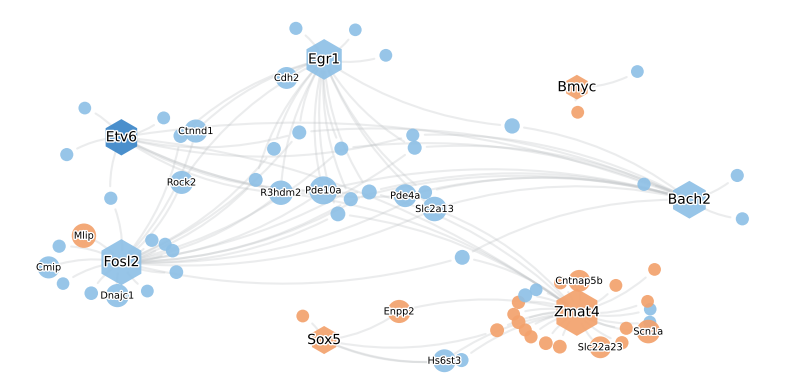

Interactive visualization saved to figures/PFC_PFC_L2-3_IT_Glut_all_comparisons_regulatory_network.html


In [19]:
# Select celltype name
selected_ctname = 'PFC_PFC_L2-3_IT_Glut'
network_source = df_tf_target_deg_hypergeom[df_tf_target_deg_hypergeom['ctname'] == selected_ctname].copy()
# 刨除NPDC1相关的行
network_source = network_source[~network_source['TF'].str.contains('Npdc1', case=False, na=False)]
network_source = network_source[network_source.comparison == 'CUSUS_M']
network_source = pd.concat([
network_source.sort_values('n_up_overlap',ascending=False).head(5),
network_source.sort_values('n_down_overlap',ascending=False).head(5)
])
network_source

if network_source.empty:
    raise ValueError(f'No rows found for ctname: {selected_ctname}')

if selected_comparison is not None:
    network_source = network_source[network_source['comparison'] == selected_comparison].copy()

if network_source['ctname'].nunique() != 1:
    raise ValueError('Network input still contains multiple ctname values.')

network_source = network_source[
    (network_source['n_up_overlap'] > 0) | (network_source['n_down_overlap'] > 0)
].copy()

def split_gene_list(value):
    if pd.isna(value) or value == '':
        return []
    return [gene.strip().upper() for gene in str(value).split(',') if gene.strip()]

edge_records = []
for _, row in network_source.iterrows():
    tf_name = str(row['TF']).upper()
    for gene in split_gene_list(row['up_deg_list']):
        edge_records.append({
            'ctname': row['ctname'],
            'comparison': row['comparison'],
            'TF': tf_name,
            'Gene': gene,
            'importance': 1,
            'importance_TF2G': 1,
            'edge_direction': 'UP'
        })
    for gene in split_gene_list(row['down_deg_list']):
        edge_records.append({
            'ctname': row['ctname'],
            'comparison': row['comparison'],
            'TF': tf_name,
            'Gene': gene,
            'importance': 1,
            'importance_TF2G': -1,
            'edge_direction': 'DOWN'
        })

network_edges = pd.DataFrame(edge_records)
if network_edges.empty:
    raise ValueError(f'No TF-gene edges found for ctname: {selected_ctname}')

network_edges = network_edges.drop_duplicates(['ctname', 'comparison', 'TF', 'Gene', 'edge_direction']).copy()

df_deg_network = df_deg_all.copy()
df_deg_network['ctname'] = df_deg_network['Region'] + '_' + df_deg_network['Subclass']
df_deg_network['ctname'] = df_deg_network['ctname'].str.replace('/', '-', regex=False)
df_deg_network['ctname'] = df_deg_network['ctname'].str.replace(' ', '_', regex=False)
df_deg_network['comparison'] = df_deg_network['Model'].str.replace(' ', '_', regex=False)

gene_col = next((col for col in ['gene', 'Gene', 'targetgene'] if col in df_deg_network.columns), None)
if gene_col is None:
    df_deg_network['gene'] = df_deg_network.index.astype(str)
else:
    df_deg_network['gene'] = df_deg_network[gene_col].astype(str)

coef_col = next((col for col in ['de_coef', 'log2FC'] if col in df_deg_network.columns), None)
if coef_col is None:
    raise KeyError('df_deg_all must contain de_coef or log2FC.')

df_deg_network = df_deg_network[df_deg_network['ctname'] == selected_ctname].copy()
if selected_comparison is not None:
    df_deg_network = df_deg_network[df_deg_network['comparison'] == selected_comparison].copy()

df_deg_network['gene'] = df_deg_network['gene'].str.upper()
df_deg_network['de_coef'] = df_deg_network[coef_col]
df_deg_network['condition'] = np.where(df_deg_network['de_coef'] > 0, 'UP', 'DOWN')
df_deg_network = df_deg_network[['gene', 'de_coef', 'condition']].drop_duplicates('gene')

comparison_label = selected_comparison if selected_comparison is not None else 'all_comparisons'
display(network_edges.head())
print(f'ctname: {selected_ctname}')
print(f'comparison: {comparison_label}')
print(f'n_edges: {len(network_edges)}')
print(f'n_tfs: {network_edges["TF"].nunique()}')
print(f'n_genes: {network_edges["Gene"].nunique()}')


visualize_regulatory_network(
    network_edges,
    importance_col='importance',
    weight_col='importance_TF2G',
    figure_size=(8,4),
    top_n=min(150, len(network_edges)),
    output_html=f'figures/{selected_ctname}_{comparison_label}_regulatory_network.html',
    title=f'',
    highlight_genes = random.sample(network_edges['Gene'].unique().tolist(), 15),
    df_deg=df_deg_network,
    tf_direction_map=dict(zip(network_source['TF'], network_source['Direction']))
)

In [20]:
df_deg_network = df_deg_all.copy()
df_deg_network['ctname'] = df_deg_network['Region'] + '_' + df_deg_network['Subclass']
df_deg_network['ctname'] = df_deg_network['ctname'].str.replace('/', '-', regex=False)
df_deg_network['ctname'] = df_deg_network['ctname'].str.replace(' ', '_', regex=False)
df_deg_network['comparison'] = df_deg_network['Model'].str.replace(' ', '_', regex=False)


In [ ]:
# Loop over all celltypes and draw one network per ctname
import random

comparison_label = 'CUSUS_M'
output_dir = 'figures/regulatory_networks'
os.makedirs(output_dir, exist_ok=True)

all_ctnames = sorted(df_tf_target_deg_hypergeom['ctname'].dropna().unique())
print(f'Total celltypes to plot: {len(all_ctnames)}')

for ct_idx, selected_ctname in enumerate(all_ctnames):
    network_source = df_tf_target_deg_hypergeom[df_tf_target_deg_hypergeom['ctname'] == selected_ctname].copy()
    # 刨除NPDC1相关的行
    network_source = network_source[~network_source['TF'].str.contains('Npdc1', case=False, na=False)]
    network_source = network_source[network_source.comparison == comparison_label]
    network_source = pd.concat([
        network_source.sort_values('n_up_overlap', ascending=False).head(5),
        network_source.sort_values('n_down_overlap', ascending=False).head(5)
    ])
    network_source = network_source[
        (network_source['n_up_overlap'] > 0) | (network_source['n_down_overlap'] > 0)
    ].copy()

    if network_source.empty:
        print(f'[skip] no network rows for {selected_ctname}')
        continue

    edge_records = []
    for _, row in network_source.iterrows():
        tf_name = str(row['TF']).upper()
        for gene in split_gene_list(row['up_deg_list']):
            edge_records.append({
                'ctname': row['ctname'],
                'comparison': row['comparison'],
                'TF': tf_name,
                'Gene': gene,
                'importance': 1,
                'importance_TF2G': 1,
                'edge_direction': 'UP'
            })
        for gene in split_gene_list(row['down_deg_list']):
            edge_records.append({
                'ctname': row['ctname'],
                'comparison': row['comparison'],
                'TF': tf_name,
                'Gene': gene,
                'importance': 1,
                'importance_TF2G': -1,
                'edge_direction': 'DOWN'
            })

    network_edges = pd.DataFrame(edge_records)
    if network_edges.empty:
        print(f'[skip] no edges for {selected_ctname}')
        continue
    network_edges = network_edges.drop_duplicates(['ctname', 'comparison', 'TF', 'Gene', 'edge_direction']).copy()

    df_deg_network_ct = df_deg_network[df_deg_network['ctname'] == selected_ctname].copy()
    if selected_comparison is not None:
        df_deg_network_ct = df_deg_network_ct[df_deg_network_ct['comparison'] == comparison_label].copy()
    df_deg_network_ct['gene'] = df_deg_network_ct['Gene'].str.upper()
    df_deg_network_ct['de_coef'] = df_deg_network_ct[coef_col]
    df_deg_network_ct['condition'] = np.where(df_deg_network_ct['de_coef'] > 0, 'UP', 'DOWN')
    df_deg_network_ct = df_deg_network_ct[['gene', 'de_coef', 'condition']].drop_duplicates('gene')

    print(f'[{ct_idx + 1}/{len(all_ctnames)}] {selected_ctname} | edges: {len(network_edges)} | TFs: {network_edges["TF"].nunique()} | genes: {network_edges["Gene"].nunique()}')

    try:
        visualize_regulatory_network(
            network_edges,
            importance_col='importance',
            weight_col='importance_TF2G',
            figure_size=(8, 4),
            top_n=min(150, len(network_edges)),
            output_html=os.path.join(output_dir, f'{selected_ctname}_{comparison_label}_regulatory_network.html'),
            title='',
            highlight_genes=random.sample(network_edges['Gene'].unique().tolist(), min(15, network_edges['Gene'].nunique())),
            df_deg=df_deg_network_ct,
            tf_direction_map=dict(zip(network_source['TF'], network_source['Direction'])),
            show_figure=False
        )
    except Exception as e:
        print(f'[error] {selected_ctname}: {e}')
        plt.close('all')
        continue

print('All celltype networks done.')

Total celltypes to plot: 215


KeyError: 'gene'